# Diabetes Risk Dataset Exploratory Data Analyis (EDA)

### Dataset Description

The dataset used in this analysis is provided by `sklearn.datasets.load_diabetes()`. It contains medical and physiological measurements collected from patients and is commonly used for diabetes-related risk and progression studies.

### What Is Diabetes?

Diabetes is a chronic health condition where **blood glucose (blood sugar) levels are too high**. Normally, the hormone **insulin** — made by the pancreas — helps glucose enter cells to be used for energy. In diabetes, the body either **doesn’t make enough insulin, can’t use it properly, or both**. This causes glucose to build up in the bloodstream, which over time can damage organs such as the **heart, kidneys, eyes, and nerves**.

---

### Why Diabetes Becomes a Problem

The main problem in diabetes is **high blood glucose** that the body cannot regulate properly. This happens because:
- The pancreas produces **little or no insulin**.
- The body’s cells become **resistant to insulin** and can’t use glucose effectively. 

Over time, prolonged high blood sugar increases the risk for serious complications like heart disease, nerve damage, kidney disease, and vision problems. Managing blood glucose is therefore essential to reduce these risks.

---

### Common Types of Diabetes

#### **Type 1 Diabetes**
This is an **autoimmune condition** — the immune system destroys the insulin-producing cells in the pancreas. People with type 1 make little or no insulin and require **daily insulin treatment**. It often appears in children or young adults, but can occur at any age.

#### **Type 2 Diabetes**
The most common form (about 90–95% of cases), type 2 diabetes develops when the body **becomes resistant to insulin** and/or doesn’t produce enough of it. It is strongly linked to lifestyle and metabolic factors.

#### **Prediabetes**
A condition where blood glucose levels are higher than normal but not yet high enough to be diagnosed as type 2 diabetes. People with prediabetes have an increased risk of developing diabetes and heart disease.

---

### Major Risk Factors

Risk factors that increase the likelihood of developing diabetes — especially type 2 — include:
- **Family history** of diabetes  
- **Overweight or obesity**
- **Physical inactivity**
- Age (risk increases with age)
- Certain racial or ethnic backgrounds  
- A history of gestational diabetes  
- Conditions like high blood pressure and high cholesterol

---

### How Common Is Diabetes?

Diabetes affects a **large number of people worldwide**. For example, in the United States:
- Over **37 million people** (about 11% of the population) had diabetes in 2019.
- **More than 90%** of cases are type 2 diabetes.
- Millions more have **prediabetes**, with blood glucose levels above normal.

Globally, hundreds of millions of people are living with diabetes, and prevalence has been rising steadily over recent decades. 

## 1. Importing Packages and Checking Data

This section imports the necessary Python libraries used throughout the analysis, including tools for data manipulation, numerical computation, visualization, and machine learning.

The diabetes dataset is loaded from `sklearn.datasets`. This dataset provides physiological features and a target variable related to disease progression, which will be used for exploratory data analysis and binary classification modeling.

In [1]:
# Import the neccessary packages
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset to perform the EDA on
from sklearn.datasets import load_diabetes

In [2]:
# Load the data and checking the overall look
diabetes_data = load_diabetes()
diabetes_data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [3]:
# Check the given description of the data
print(diabetes_data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [4]:
df = pd.DataFrame(diabetes_data.data, columns=diabetes_data.feature_names)
df["target"] = diabetes_data.target
df.sample(5)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
245,-0.027310,-0.044642,-0.035307,-0.029770,-0.056607,-0.058620,0.030232,-0.039493,-0.049872,-0.129483,125.0
63,-0.034575,-0.044642,-0.037463,-0.060756,0.020446,0.043466,-0.013948,-0.002592,-0.030748,-0.071494,128.0
89,-0.045472,-0.044642,-0.048241,-0.019442,-0.000193,-0.016032,0.067048,-0.039493,-0.024795,0.019633,111.0
378,0.016281,0.050680,0.002417,-0.005670,-0.005697,0.010899,-0.050764,0.034309,0.022688,-0.038357,245.0
369,-0.009147,-0.044642,0.037984,-0.040099,-0.024960,-0.003819,-0.043401,0.015858,-0.005142,0.027917,167.0


### 1.1 Dataset Preparation

Based on the dataset description and inspection of the sample values, the data appears to have been **mean-centered**.

For clearer interpretation, we will instead use the **original dataset prior to mean centering for EDA**.

**Prior mean-centering dataset:**  
https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt

In [5]:
# If viewed on mac to bypass SSL cert problem:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

original_data_url = "https://www4.stat.ncsu.edu/~boos/var.select/diabetes.tab.txt"

original_data_df = pd.read_csv(original_data_url, sep="\t")
original_data_df.sample(5)

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
390,51,2,32.8,112.00,202,100.6,37.0,5.00,5.7746,109,277
329,45,2,21.2,94.00,169,96.8,55.0,3.00,4.4543,102,135
40,50,2,25.6,101.00,229,162.2,43.0,5.00,4.7791,114,100
170,55,2,24.5,84.00,179,105.8,66.0,3.00,3.5835,87,47
167,68,1,32.8,105.67,205,116.4,40.0,5.13,5.4931,117,220


### 1.2 Observations of data integrity

In [6]:
# Check the shape of the dataset
print(f"Shape of the original dataset: {original_data_df.shape}")
print("---")

# Check for NULL / NaN values
print(
    "Number of NULL data points in each column:\n"
    f"{original_data_df.isna().sum()}"
)
print("---")

# Check for duplicated rows
print(
    f"Number of duplicated rows inside the dataset: "
    f"{original_data_df.duplicated().sum()}"
)

Shape of the original dataset: (442, 11)
---
Number of NULL data points in each column:
AGE    0
SEX    0
BMI    0
BP     0
S1     0
S2     0
S3     0
S4     0
S5     0
S6     0
Y      0
dtype: int64
---
Number of duplicated rows inside the dataset: 0


In [7]:
original_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


In [8]:
original_data_df.describe()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


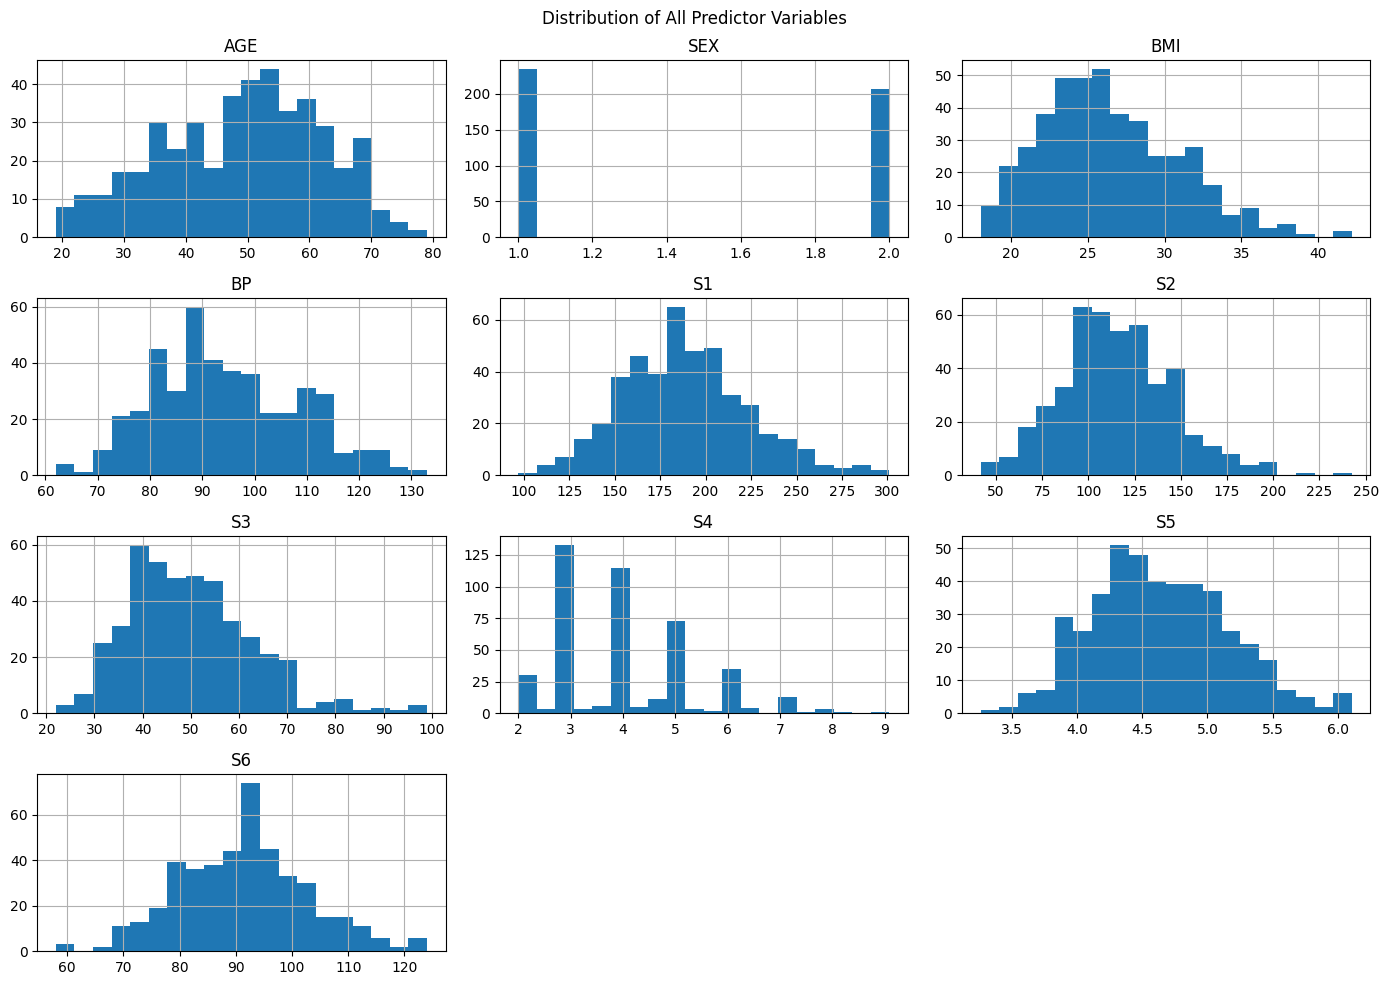

In [42]:
# Quick overview of all variables at once
original_data_df.drop(columns=['Y']).hist(figsize=(14, 10), bins=20)
plt.suptitle('Distribution of All Predictor Variables')
plt.tight_layout()
plt.show()

- The dataset contains **442 observations (rows)** indexed from 0 to 441.
- There are **11 total columns** in the dataset.
- All columns contain **442 non-null values**, indicating:
  - No missing values are present.
  - The dataset is complete and ready for analysis without imputation.
- 0 duplicated values are present in the dataset

- Data types:
  - **6 columns are `float64`**
  - **5 columns are `int64`**
This suggests a mix of continuous and discrete variables but object and str types are not present in the dataset

- Visualization:
  - The histograms below show the distribution of each predictor variable across 
  - Most clinical variables such as AGE, BMI, BP, S1 and S2 approximate a normal distribution
  - S3 shows a right skew and S4 displays a discrete stepped pattern reflecting its nature as a derived ratio. 
  - SEX is strictly binary and S5, S6 are tightly concentrated around their means.

### 1.3 Outlier Detection

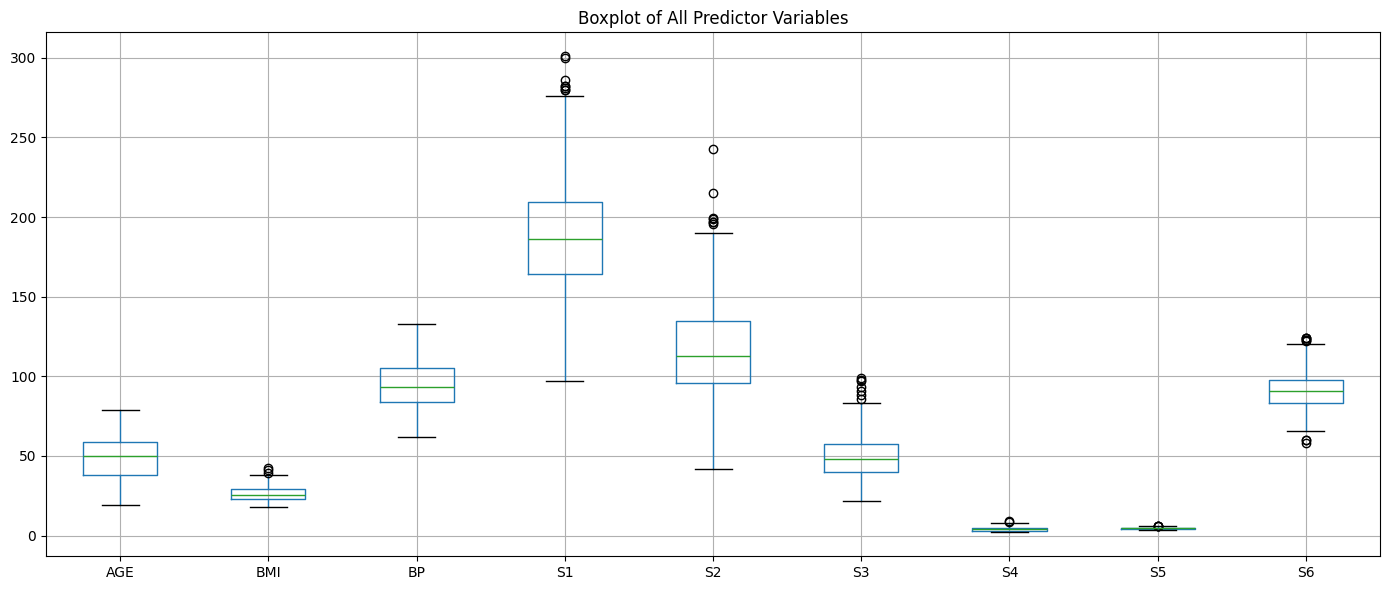

In [ ]:
original_data_df.drop(columns=['Y', 'SEX']).boxplot(figsize=(14, 6))
plt.title('Boxplot of All Predictor Variables')
plt.tight_layout()
plt.show()

In [ ]:
# IQR calculation for target variable Y
Q1 = original_data_df["Y"].quantile(0.25)
Q3 = original_data_df["Y"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count outliers
outliers_Y = original_data_df[
    (original_data_df["Y"] < lower_bound) | 
    (original_data_df["Y"] > upper_bound)
]

print("Number of extreme outliers in Y:", len(outliers_Y))
print("Percentage of dataset:", round(len(outliers_Y) / len(original_data_df) * 100, 2), "%")

Q1: 87.0
Q3: 211.5
IQR: 124.5
Lower Bound: -99.75
Upper Bound: 398.25
Number of extreme outliers in Y: 0
Percentage of dataset: 0.0 %


In [ ]:
# IQR-based outlier detection for all numeric columns
outlier_summary = {}

for col in original_data_df.drop(columns=['scenario_1','scenario_2']).columns:
    Q1 = original_data_df[col].quantile(0.25)
    Q3 = original_data_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = original_data_df[
        (original_data_df[col] < lower) | 
        (original_data_df[col] > upper)
    ]
    
    outlier_summary[col] = len(outliers)

# Convert to DataFrame for cleaner display
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier Count'])
outlier_df["Outlier Percentage"] = (outlier_df["Outlier Count"] / len(original_data_df)) * 100

outlier_df.sort_values(by="Outlier Count", ascending=False)

,Outlier Count,Outlier Percentage
S6,9,2.036199
S1,8,1.809955
S3,7,1.583710
S2,7,1.583710
S5,4,0.904977
BMI,3,0.678733
S4,2,0.452489
SEX,0,0.000000
AGE,0,0.000000
BP,0,0.000000


**Outlier Detection — IQR Method**
- **S6 (2.0%), S1 (1.8%), S3 and S2 (1.6%)** contain the most outliers, 
  all of which are dropped features — so outliers in these variables will 
  not affect modeling.
- **S5 (0.9%)** and **BMI (0.7%)** have a small number of outliers among 
  the retained features, representing fewer than 4 patients each — 
  not significant enough to warrant removal.
- **AGE, SEX, BP and Y have zero outliers**, confirming the dataset is 
  clean for the target variable and key clinical predictors.
- Since Y has no outliers, both scenario thresholds (150 and 250) are 
  applied to the full 442-patient dataset without any row removal.

### 1.4 Target Variable Analysis

The target variable **Y** represents a **quantitative measure of disease progression one year after baseline**. It is a continuous variable ranging from 25 to 346, with a mean of approximately 152 and a standard deviation of ~77, indicating considerable variability in disease progression across patients.



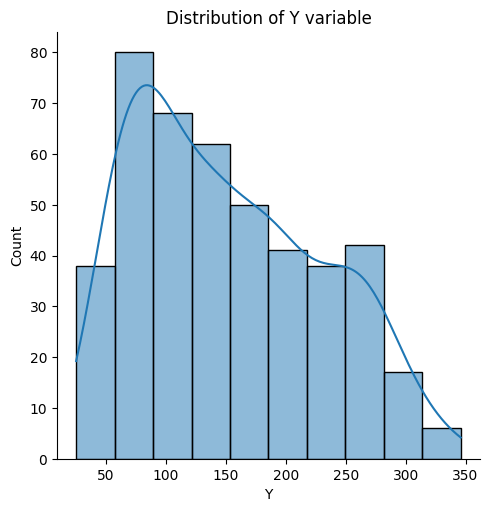

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: Y, dtype: float64

In [9]:
# Check the distribution of the "Y" variables data

sns.displot(original_data_df["Y"], kde=True)
plt.title("Distribution of Y variable")
plt.show()

# Save figure for use later
# plt.savefig('../docs/figures/target_variable_analysis/normal_distribution_displot')

# Check back the tendecies:
original_data_df['Y'].describe()

scenario_1
Not Endangered    242
Endangered        200
Name: count, dtype: int64
scenario_1
Not Endangered    54.751131
Endangered        45.248869
Name: proportion, dtype: float64


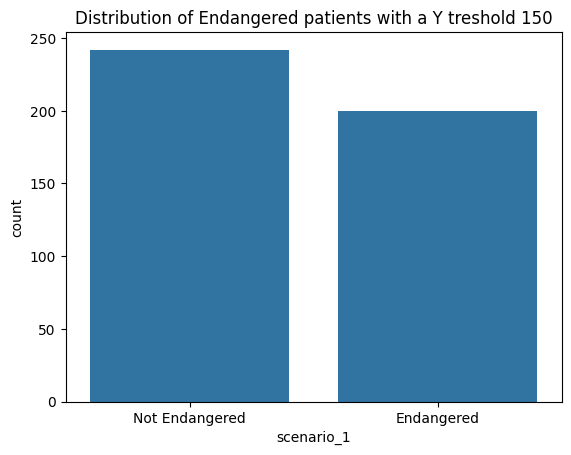

In [10]:
# Check the distributio of data based on the two tresholds which is 150 and 250

original_data_df['scenario_1'] = original_data_df['Y'].gt(150).map({True: "Endangered", False: "Not Endangered"})

# Counts of data
print(original_data_df['scenario_1'].value_counts())

# Percentage of data
print(original_data_df['scenario_1'].value_counts(normalize=True) * 100)

sns.countplot(x='scenario_1', data=original_data_df, order=['Not Endangered', 'Endangered'])
plt.title('Distribution of Endangered patients with a Y treshold 150')
plt.show()

# Save figure for use later
# plt.savefig('../docs/figures/target_variable_analysis/scenarion_1_countplot')

#### Scenario 1: Y > 150 (Endangered Classification)

**Key Observations**

- **Total sample size:** 442 patients  
- **Not Endangered:** 242 patients (54.75%)  
- **Endangered:** 200 patients (45.25%)

**Class Distribution**

The dataset is relatively balanced under the threshold of 150.  
Approximately 45% of patients are classified as *Endangered*, while 55% are *Not Endangered*.  

**Threshold Interpretation**

- Nearly half of the population exceeds the threshold.
- This suggests that **150 represents a moderate risk boundary** rather than an extreme cutoff.
- Small adjustments to the threshold could significantly shift the class proportions.

**Modeling Implications**

Since the class distribution is close to balanced:
- Advanced resampling techniques (e.g., SMOTE) may not be necessary.
- Standard classification approaches should perform reliably without major bias toward one class.

scenario_2
Not Endangered    377
Endangered         65
Name: count, dtype: int64
scenario_2
Not Endangered    85.294118
Endangered        14.705882
Name: proportion, dtype: float64


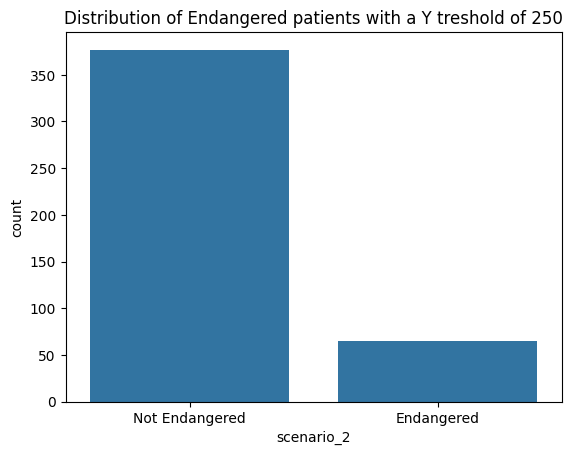

<Figure size 640x480 with 0 Axes>

In [11]:
original_data_df['scenario_2'] = original_data_df['Y'].gt(250).map({True: "Endangered", False: "Not Endangered"})

# Counts of data
print(original_data_df['scenario_2'].value_counts())

# Percentage of data
print(original_data_df['scenario_2'].value_counts(normalize=True) * 100)


sns.countplot(x='scenario_2', data=original_data_df, order=['Not Endangered', 'Endangered'])
plt.title('Distribution of Endangered patients with a Y treshold of 250')
plt.show()

# Save figure for use later
plt.savefig('../docs/figures/target_variable_analysis/scenarion_2_countplot')

#### Scenario 2: Y > 250 (Endangered Classification)

**Key Observations**

- **Total sample size:** 442 patients  
- **Not Endangered:** 377 patients (85.29%)  
- **Endangered:** 65 patients (14.71%)

**Class Distribution**

The dataset becomes strongly imbalanced under the threshold of 250.  
Only 14.7% of patients are classified as *Endangered*, while 85.3% fall into the *Not Endangered* category.

This indicates that the threshold of 250 represents a much stricter or more extreme risk boundary.

**Threshold Interpretation**

- A relatively small proportion of the population exceeds this higher threshold.
- The cutoff of 250 isolates a high-risk subgroup.
- Compared to the 150 threshold, this value captures only the upper tail of the Y distribution.

**Modeling Implications**

Due to the strong class imbalance:

- Predictive models may become biased toward the majority class.
- Accuracy alone would not be an appropriate evaluation metric.

### 1.5 Correlation and Multicollenarity check

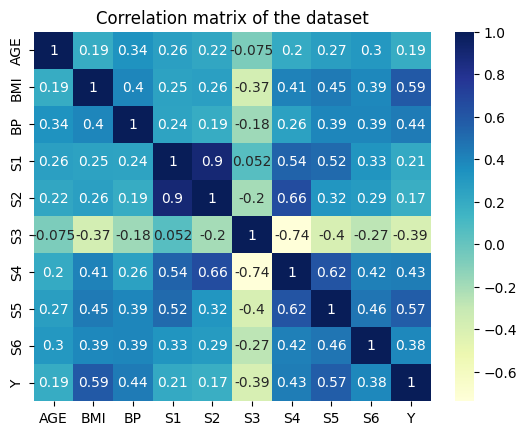

<Figure size 640x480 with 0 Axes>

In [25]:
# Create the correlation matrix
co_mtx = original_data_df.drop(columns=["SEX"]).corr(numeric_only=True) 

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.title('Correlation matrix of the dataset')
plt.show()

plt.savefig('../docs/figures/correlation_figures/correlation_heatmap')

#### Target Variable (Y) — Key Predictors
- **BMI (0.59)** and **S5 (0.57)** are the strongest positive predictors of Y
- **BP (0.44)** and **S4 (0.43)** also show meaningful positive correlations with Y
- **S3 (-0.39)** has a moderate **negative** correlation with Y — as S3 increases, 
  diabetes progression decreases (consistent with S3 being HDL cholesterol, 
  where higher HDL is protective)

#### Multicollinearity Concerns
- **S1 ↔ S2 (0.90)** — near-perfect correlation, these two features carry almost 
  identical information and cannot both be kept in a linear model
- **S3 ↔ S4 (-0.74)** — strong inverse relationship, likely reflecting the 
  biochemical link between HDL cholesterol (S3) and total/LDL cholesterol ratios (S4)
- **S4 ↔ S5 (0.62)** — moderate but notable overlap between these serum markers, 
  worth investigating further


- **AGE (0.19)** and **SEX** show weak correlations with Y and with most 
  other features, suggesting limited standalone predictive power

In [13]:
# Checking multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = original_data_df.drop(columns=["Y", "scenario_1", "scenario_2"]).astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]
vif_data

,feature,VIF
0,AGE,17.876909
1,SEX,12.192347
2,BMI,55.155355
3,BP,69.404363
4,S1,576.886424
5,S2,244.913298
6,S3,52.293365
7,S4,81.350054
8,S5,277.183350
9,S6,93.976986


#### Initial VIF Results (Full Feature Set)
Running the Variance Inflation Factor on the full dataset revealed severe
multicollinearity across the blood serum measurement variables (S1-S6):

- **S1 — Total Serum Cholesterol (576.9)** and **S2 — LDL (244.9)** showed
  very high VIF scores, consistent with their near-perfect 
  correlation of 0.90 in the correlation matrix. This is expected as LDL 
  is a direct component of total serum cholesterol.
- **S5 — Log Serum Triglycerides (277.2)** was severely inflated due to its 
  biochemical overlap with the broader cholesterol profile
- **S4 — Total Cholesterol/HDL Ratio (81.4)** and **S6 — Blood Sugar (94.0)** 
  both far exceeded the problematic threshold of 30
- **BMI (55.2)** and **BP (66.6)** were also elevated, forming a secondary 
  collinearity cluster with the serum variables
- Only **AGE (17.9)** and **SEX (12.2)** were relatively acceptable, 
  though still above 10

This confirms that S1-S6 are measuring overlapping aspects of the same 
underlying metabolic and cholesterol profile, making several of them redundant.

In [14]:
# Droping S1, S2, S4, S6
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = original_data_df.drop(columns=["Y", "scenario_1", "scenario_2", "S1", "S2", "S4","S6"]).astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                   for i in range(X.shape[1])]
vif_data

,feature,VIF
0,AGE,17.295551
1,SEX,10.818948
2,BMI,48.942902
3,BP,66.621240
4,S3,11.694292
5,S5,77.435409


#### Key Observations

- **S3 (HDL Cholesterol)** is the only serum variable that reached an 
  acceptable VIF level (11.7) after the feature reduction, confirming 
  that removing the other cholesterol fractions successfully isolated it 
  as an independent predictor
- **SEX (10.8)** sits just above the threshold of 10, borderline acceptable
- **AGE (17.3)** remains moderately inflated, suggesting it shares some 
  variance with BMI and BP — which is clinically expected as age correlates 
  with both weight gain and rising blood pressure
- **BMI (48.9)** and **BP (66.6)** form a persistent collinearity cluster 
  with each other and with S5, reflecting the well-known medical relationship 
  between obesity, hypertension and triglyceride levels
- **S5 (77.4)** remains the most problematic feature but is retained due to 
  its strong predictive value for Y (correlation: 0.57)

### 1.6 Bivariate Exploration

It is worth exploring how the AGE distribution differs across the two SEX 
groups in the dataset, to understand whether one group skews older or younger 
and how spread out the ages are within each group.

C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\1473666506.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="SEX", y="AGE",


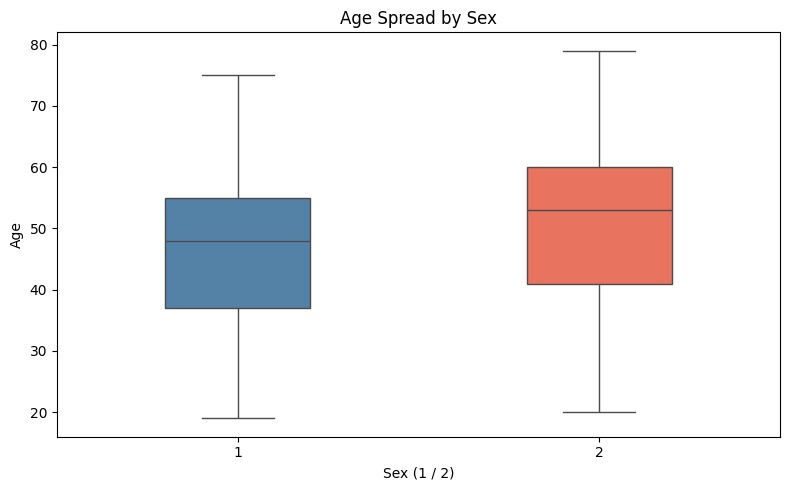

<Figure size 640x480 with 0 Axes>

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=original_data_df, x="SEX", y="AGE",
            palette=["steelblue", "tomato"],
            width=0.4, ax=ax)

ax.set_title("Age Spread by Sex")
ax.set_xlabel("Sex (1 / 2)")
ax.set_ylabel("Age")

plt.tight_layout()
plt.show()

plt.savefig('../docs/figures/bivariate_exploration/age_spread_by_sex_boxplot')

**Observations**
- **Group 1 (Sex = 1)** has a median age around 47-48 with a symmetric spread (IQR: 38-55).
- **Group 2 (Sex = 2)** skews slightly older with a median around 52-53 and a wider IQR (43-60).
- Both groups share a similar overall range of 20-80 years with no extreme outliers.
- Group 2 patients tend to be slightly older, though SEX showed a weak Y correlation (0.19) so this is unlikely to be a strong model driver.

BMI is the strongest predictor so it is worth exploring how it directly affects disease progression.

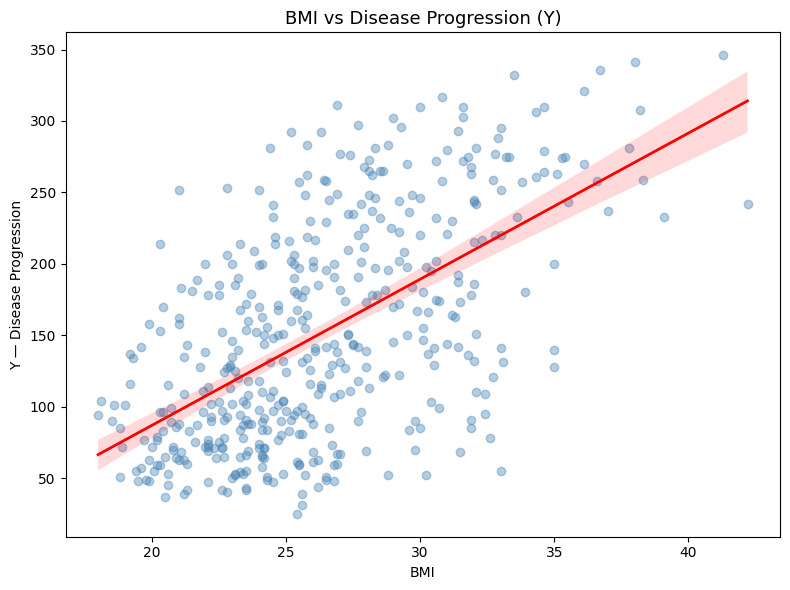

<Figure size 640x480 with 0 Axes>

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(data=original_data_df, x="BMI", y="Y",
            scatter_kws={"alpha": 0.4, "color": "steelblue"},
            line_kws={"color": "red", "linewidth": 2},
            ax=ax)

ax.set_title("BMI vs Disease Progression (Y)", fontsize=13)
ax.set_xlabel("BMI")
ax.set_ylabel("Y — Disease Progression")
plt.tight_layout()
plt.show()

plt.savefig('../docs/figures/bivariate_exploration/BMI_vs_target_value_regplot')

C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\2937565757.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=original_data_df, x="BMI_GROUP", y="Y",


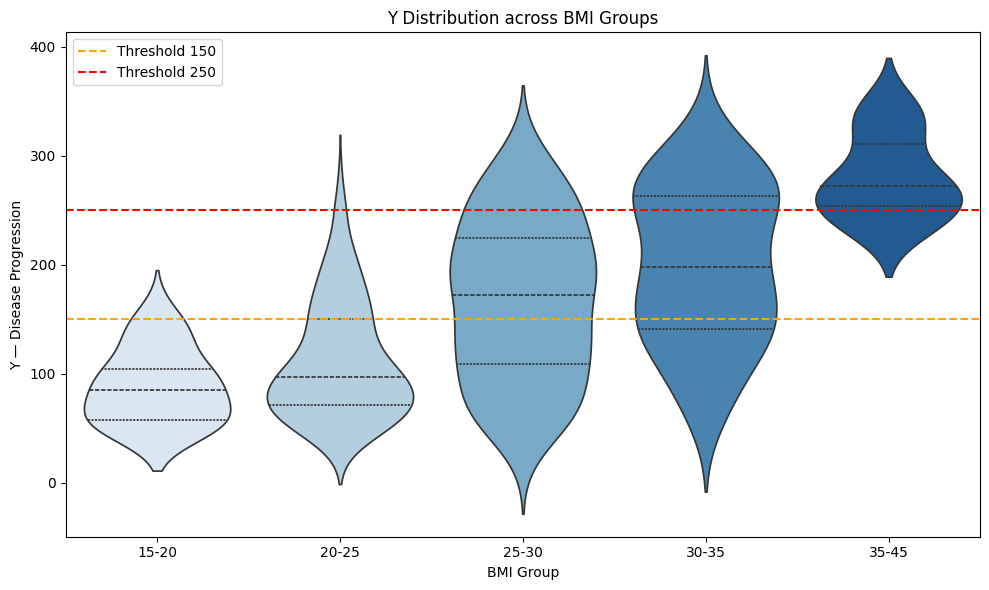

<Figure size 640x480 with 0 Axes>

In [31]:
# Bin BMI into ranges
original_data_df["BMI_GROUP"] = pd.cut(
    original_data_df["BMI"],
    bins=[15, 20, 25, 30, 35, 45],
    labels=["15-20", "20-25", "25-30", "30-35", "35-45"]
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=original_data_df, x="BMI_GROUP", y="Y",
               palette="Blues", inner="quart", ax=ax)

ax.set_title("Y Distribution across BMI Groups")
ax.set_xlabel("BMI Group")
ax.set_ylabel("Y — Disease Progression")
ax.axhline(150, color="orange", linewidth=1.5, linestyle="--", label="Threshold 150")
ax.axhline(250, color="red", linewidth=1.5, linestyle="--", label="Threshold 250")
ax.legend()

plt.tight_layout()
plt.show()

plt.savefig('../docs/figures/bivariate_exploration/y_distribution_by_BMI_violinplot')

- **Strong positive relationship** — higher BMI consistently leads to higher 
  disease progression (r = 0.59).
- **BMI 30+ is the at-risk tipping point** — from the violin plot, the 30-35 
  group is the first where the bulk of distribution crosses the 150 threshold.
- **BMI 35-45 patients are predominantly high-risk** — the majority sit above 
  both the 150 and 250 thresholds.
- **Low BMI (15-25) is largely protective** — almost all patients in these 
  groups fall below the 150 threshold.
- **High variance at BMI 25-30** — the widest violin and highest scatter spread 
  occurs here, making this the least predictable group for disease progression.

Since BMI and BP both showed elevated VIF scores and a positive correlation it is worth exploring whether they compound each other's effect on disease progression.

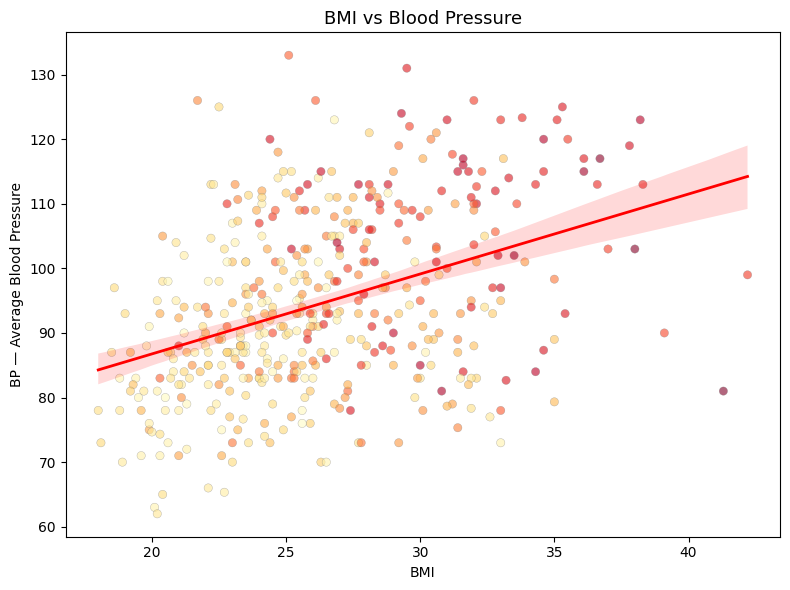

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    original_data_df["BMI"],
    original_data_df["BP"],
    c=original_data_df["Y"],
    cmap="YlOrRd",
    alpha=0.6,
    edgecolors="grey",
    linewidth=0.3
)

sns.regplot(data=original_data_df, x="BMI", y="BP",
            scatter=False,
            line_kws={"color": "red", "linewidth": 2},
            ax=ax)

ax.set_title("BMI vs Blood Pressure", fontsize=13)
ax.set_xlabel("BMI")
ax.set_ylabel("BP — Average Blood Pressure")
plt.tight_layout()
plt.show()

- **BMI and BP are positively correlated** — as BMI rises, blood pressure 
  tends to increase, confirming their VIF cluster (BMI: 48.9, BP: 66.6).
- **Darker points concentrate at higher BMI and BP** — the highest Y values 
  (deep red) appear mostly where both BMI > 30 and BP > 100, suggesting 
  these two variables compound each other's effect on progression.
- **High BP alone is not sufficient** — several high BP patients (110-130) 
  with low BMI show yellow/low Y values, meaning BP without elevated BMI 
  is less predictive.
- **The combined effect matters** — the most at-risk patients sit in the 
  top-right corner, reinforcing that BMI and BP together are stronger 
  predictors than either individually.

S3(HDL Cholestarel) is also a strong predictor with a negative correlation so it also worth to see how it moves with the target valuable

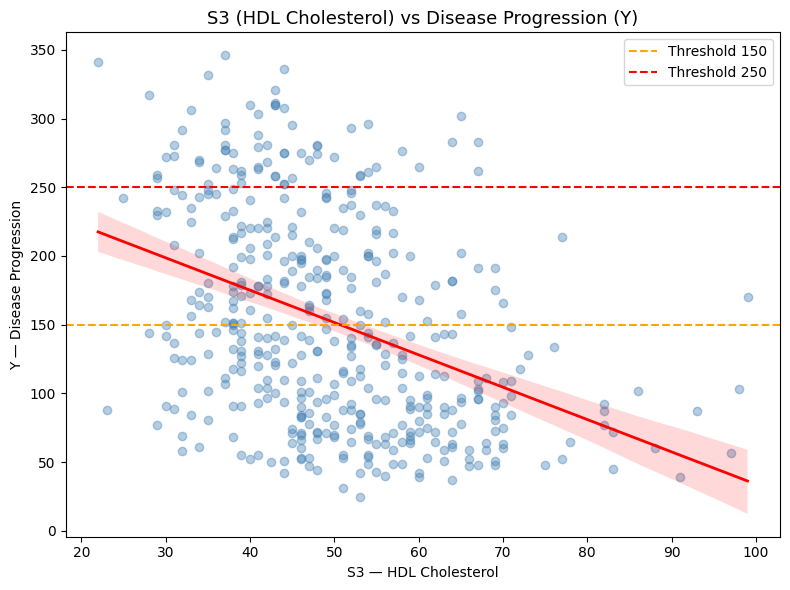

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(data=original_data_df, x="S3", y="Y",
            scatter_kws={"alpha": 0.4, "color": "steelblue"},
            line_kws={"color": "red", "linewidth": 2},
            ax=ax)

ax.set_title("S3 (HDL Cholesterol) vs Disease Progression (Y)", fontsize=13)
ax.set_xlabel("S3 — HDL Cholesterol")
ax.set_ylabel("Y — Disease Progression")
ax.axhline(150, color="orange", linewidth=1.5, linestyle="--", label="Threshold 150")
ax.axhline(250, color="red", linewidth=1.5, linestyle="--", label="Threshold 250")
ax.legend()

plt.tight_layout()
plt.show()

- **Clear negative relationship** — as HDL cholesterol increases, disease 
  progression decreases consistently (r = -0.39), confirming S3 as a 
  protective factor against diabetes progression.
- **Low S3 patients (20-40) cluster heavily above both thresholds**, 
  meaning low HDL is a strong indicator of at-risk and high-risk progression.
- **Wide variance at mid-range S3 (40-60)** — the confidence band widens 
  here, making HDL a less reliable sole predictor in the normal range.

Important to look at feature distribution for both scenario 1 and scenario 2 to better understand the possible main feauterest for the model training and building

C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\2213592398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="scenario_1", y=feat,
C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\2213592398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="scenario_1", y=feat,
C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\2213592398.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="scenario_1", y=feat,
C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\2213592398.py:7: Futu

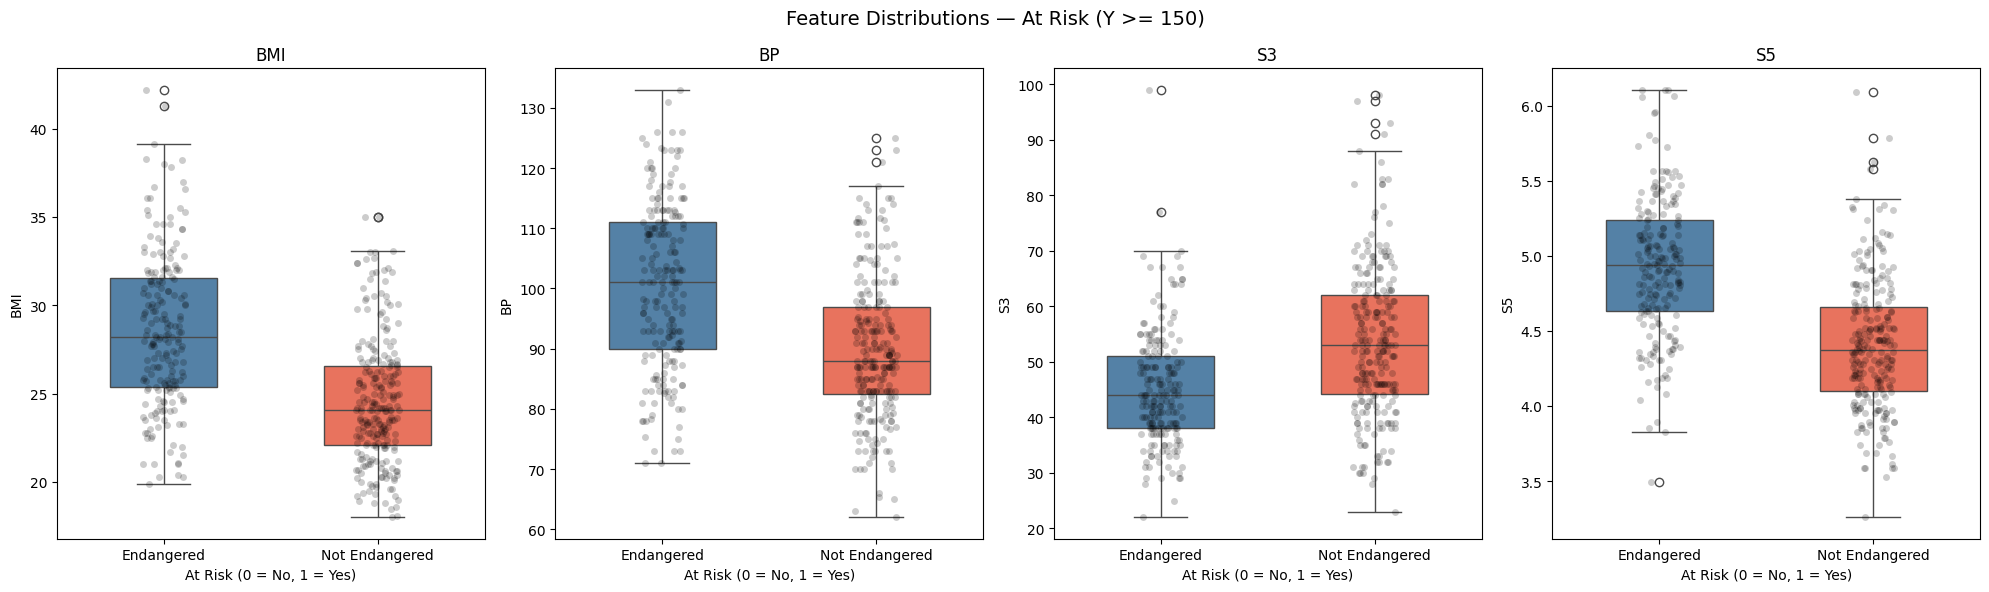

In [40]:
features = ["BMI", "BP", "S3", "S5"]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Feature Distributions — At Risk (Y >= 150)", fontsize=14)

for i, feat in enumerate(features):
    sns.boxplot(data=original_data_df, x="scenario_1", y=feat,
                palette=["steelblue", "tomato"],
                width=0.5, ax=axes[i])
    sns.stripplot(data=original_data_df, x="scenario_1", y=feat,
                  color="black", alpha=0.2, jitter=True, ax=axes[i])
    axes[i].set_title(f"{feat}")
    axes[i].set_xlabel("At Risk (0 = No, 1 = Yes)")
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.show()

**Scenario 1 — At Risk (Y >= 150)**
- **BMI** shows a clear upward shift for at-risk patients, confirming it as 
  the strongest separator at the 150 threshold.
- **BP** median is noticeably higher in the at-risk group, supporting its 
  role as a secondary predictor.
- **S3 (HDL)** median is lower in at-risk patients, consistent with its 
  negative Y correlation — lower HDL associates with higher progression.
- **S5 (Log Triglycerides)** is visibly elevated in the at-risk group, 
  confirming its predictive value despite high VIF.

C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\4211298130.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="scenario_2", y=feat,
C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\4211298130.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="scenario_2", y=feat,
C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\4211298130.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=original_data_df, x="scenario_2", y=feat,
C:\Users\mmarc\AppData\Local\Temp\ipykernel_9876\4211298130.py:7: Futu

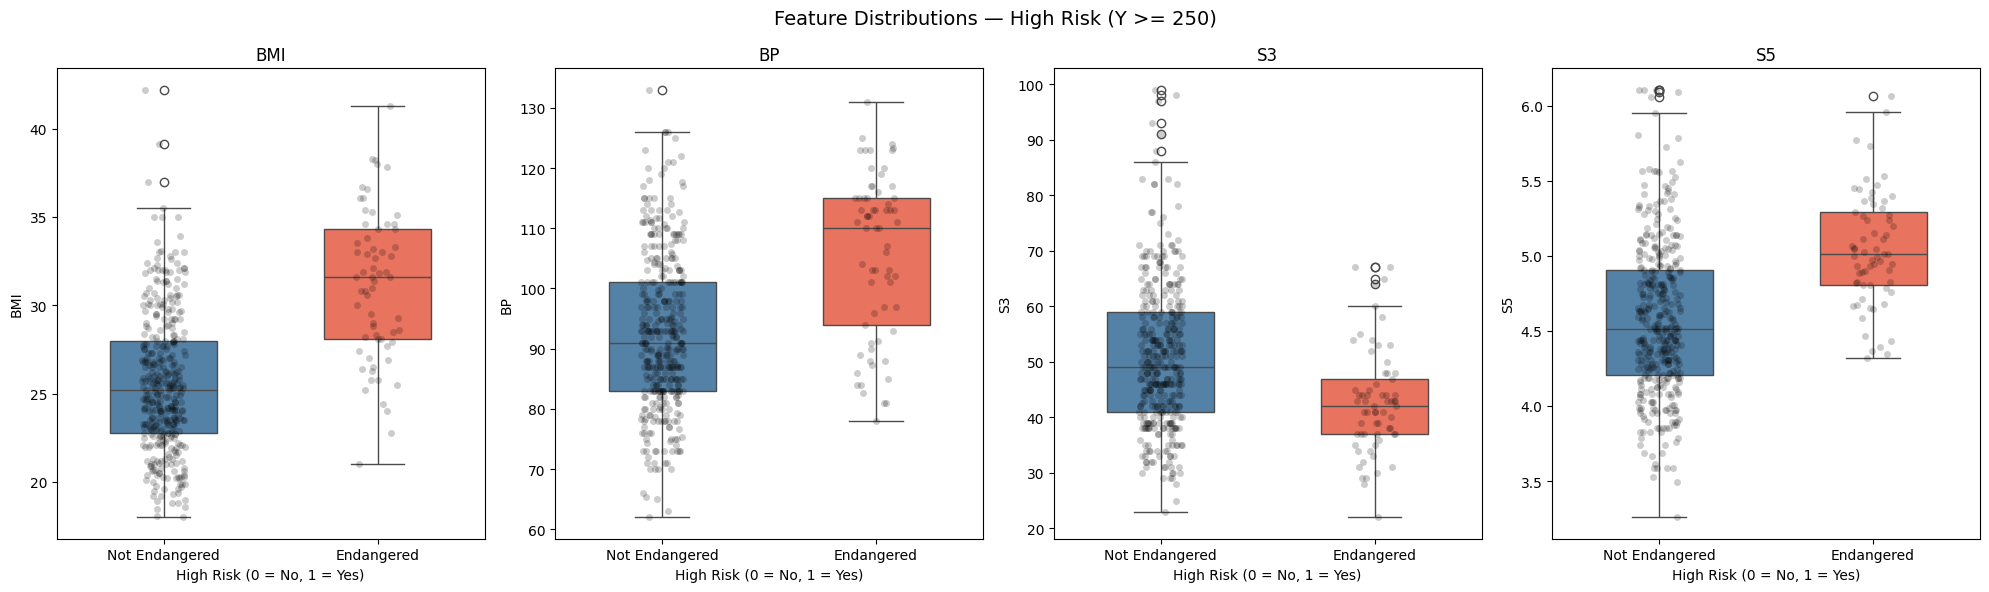

In [41]:
features = ["BMI", "BP", "S3", "S5"]

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Feature Distributions — High Risk (Y >= 250)", fontsize=14)

for i, feat in enumerate(features):
    sns.boxplot(data=original_data_df, x="scenario_2", y=feat,
                palette=["steelblue", "tomato"],
                width=0.5, ax=axes[i])
    sns.stripplot(data=original_data_df, x="scenario_2", y=feat,
                  color="black", alpha=0.2, jitter=True, ax=axes[i])
    axes[i].set_title(f"{feat}")
    axes[i].set_xlabel("High Risk (0 = No, 1 = Yes)")
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.show()

**Scenario 2 — High Risk (Y >= 250)**
- **BMI and S5** show the clearest separation between groups, making them 
  the most reliable features for the stricter 250 threshold.
- **BP** separation is less pronounced than in Scenario 1, suggesting it 
  becomes a weaker differentiator at higher progression levels.
- **S3** continues its protective pattern — high-risk patients consistently 
  show lower HDL values.
- The high-risk group (Y >= 250) has fewer positive cases, meaning the 
  boxplots show more overlap between classes — class imbalance will need 
  to be addressed at the modeling stage.

## 2. EDA Conclusion & Modeling Strategy

### Retained Feature Set
Based on the correlation analysis, VIF reduction and bivariate exploration, 
the following features are retained for modeling:
**BMI, BP, S3 (HDL), S5 (Log Triglycerides), AGE, SEX**

Dropped features (S1, S2, S4, S6) were removed due to severe multicollinearity 
confirmed by both VIF scores and pairwise correlations above 0.74.

### Scenario 1 — Binary Classifier (Y >= 150)
- Approximately 50% of patients fall above the 150 threshold given the 
  median Y of 140.5, meaning this scenario will have a **roughly balanced 
  class distribution**
- A standard **Logistic Regression or Random Forest** classifier is appropriate
- Class weighting unlikely to be required but should be verified

### Scenario 2 — Binary Classifier (Y >= 250)
- The 250 threshold is significantly stricter — fewer patients will be 
  positive cases, creating **likely class imbalance**
- A **Random Forest or Gradient Boosting** model is preferred here due to 
  its robustness to both multicollinearity (S5 VIF: 77) and imbalanced classes
- `class_weight='balanced'` or **SMOTE** should be considered depending 
  on the confirmed class ratio

### Key Modeling Considerations
- S5 retains a high VIF (77.4) — tree-based models are preferred over 
  logistic regression to avoid unstable coefficients
- No outlier removal is needed — Y has zero outliers across the full dataset
- Both models share the same feature set, allowing direct comparison of 
  performance across the two risk thresholds